<a href="https://colab.research.google.com/github/OlorteguiKevin/lab07/blob/develop/Lab07_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

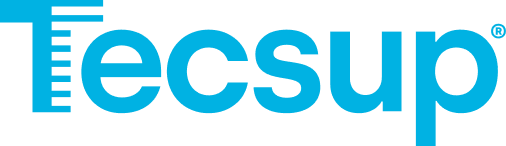

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 7
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

Indicaciones:
- El trabajo en su totalidad debe ser hecho en un notebook de ‘Jupyter’.
- Cree una cabecera que lleve por título el tema de la semana y debajo de él coloque un ‘Markdown’ con su nombre y apellido.
- Ejecute su notebook, grábelo, descárguelo como HTML, conviértalo a PDF y suba ambos archivos en el apartado que el docente indique.

Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando las librerías de Python que se indican, haga lo siguiente:

## Actividad A
Calcule el information value (IV), tanto para el grupo de variable numéricas como categóricas y excluya las que tenga un poder predictivo débil o menor. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import statsmodels.api as sm

In [2]:
# 1. Load data from the UCI repository
def clean_data(df):
    """
    This function imputes missing values using the median for each column.
    input:
    - df: (pd.DataFrame) DataFrame potentially containing missing values.
    output:
    - df_clean: (pd.DataFrame) DataFrame with missing values imputed.
    """
    df_clean = df.copy()
    for col in df_clean.columns:
        if df_clean[col].isnull().any():
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
    return df_clean

In [3]:
# 2. Data cleaning function
def load_data(url):
    """
    This function loads the Wisconsin breast cancer dataset and cleans it.
    input:
    - url: (str) URL to the dataset file.
    output:
    - df: (pd.DataFrame) DataFrame with imputed missing values and binary target column.
    """
    cols = [
        'id', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape',
        'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei',
        'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'
    ]
    df = pd.read_csv(url, names=cols, na_values='?')
    df = clean_data(df)
    df['bare_nuclei'] = df['bare_nuclei'].astype(int)
    df['target'] = df['class'].map({2: 0, 4: 1})
    df.drop(['id', 'class'], axis=1, inplace=True)
    return df

In [4]:
# 3. Calculate WOE and Information Value (IV)
def calc_iv(df, feature, target, bins=10):
    """
    This function computes WOE and IV for a single feature.
    input:
    - df: (pd.DataFrame) DataFrame containing the feature and target.
    - feature: (str) Column name of the feature to evaluate.
    - target: (str) Column name of the binary target variable.
    - bins: (int) Number of quantile bins for numeric features.
    output:
    - iv: (float) Information Value of the feature.
    - agg: (pd.DataFrame) Aggregated DataFrame containing WOE calculation per bin.
    """
    data = df[[feature, target]].copy()
    if pd.api.types.is_numeric_dtype(data[feature]):
        data['bin'] = pd.qcut(data[feature], bins, duplicates='drop')
    else:
        data['bin'] = data[feature]
    agg = data.groupby('bin', observed=False)[target].agg(['count', 'sum']).rename(columns={'sum': 'bad'})
    agg['good'] = agg['count'] - agg['bad']
    agg['dist_bad'] = agg['bad'] / agg['bad'].sum()
    agg['dist_good'] = agg['good'] / agg['good'].sum()
    agg = agg[(agg['dist_bad'] > 0) & (agg['dist_good'] > 0)]
    agg['woe'] = np.log(agg['dist_good'] / agg['dist_bad'])
    agg['iv'] = (agg['dist_good'] - agg['dist_bad']) * agg['woe']
    iv = agg['iv'].sum()
    return iv, agg

In [5]:
# 4. Feature selection based on IV
def select_features_by_iv(df, target, threshold=0.02):
    """
    This function selects features whose IV exceeds a threshold.
    input:
    - df: (pd.DataFrame) DataFrame containing features and target.
    - target: (str) Column name of the binary target variable.
    - threshold: (float) Minimum IV value for feature selection.
    output:
    - selected: (list) Feature names with IV >= threshold.
    - iv_values: (dict) Mapping of feature names to their IV values.
    """
    iv_values = {}
    for col in df.columns:
        if col == target:
            continue
        iv, _ = calc_iv(df, col, target)
        iv_values[col] = iv
    selected = [k for k, v in iv_values.items() if v >= threshold]
    return selected, iv_values

In [6]:
# 5. Split data into training and testing sets
def split_data(df, features, target, test_size=0.25, random_state=42):
    """
    This function splits data into train and test sets.
    input:
    - df: (pd.DataFrame) DataFrame with data.
    - features: (list) List of predictor column names.
    - target: (str) Column name of the binary target variable.
    - test_size: (float) Proportion of data for testing.
    - random_state: (int) Random seed for reproducibility.
    output:
    - X_train: (pd.DataFrame) Training predictors.
    - X_test: (pd.DataFrame) Testing predictors.
    - y_train: (pd.Series) Training target.
    - y_test: (pd.Series) Testing target.
    """
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

In [7]:
# 6. Train and evaluate Logistic Regression model
def train_evaluate_logistic(X_train, y_train, X_test, y_test):
    """
    This function trains logistic regression, computes confusion matrix, and evaluates performance.
    input:
    - X_train: (pd.DataFrame) Training predictors.
    - y_train: (pd.Series) Training target.
    - X_test: (pd.DataFrame) Testing predictors.
    - y_test: (pd.Series) Testing target.
    output:
    - lr: (LogisticRegression) Trained model.
    - metrics: (dict) Classification metrics: accuracy, precision, recall, F1, ROC AUC.
    - cm: (np.ndarray) Confusion matrix [[tn, fp], [fn, tp]].
    - summary: (pd.DataFrame) Coefficient significance table from statsmodels.
    """
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    y_proba = lr.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    X_sm = sm.add_constant(X_train)
    sm_model = sm.Logit(y_train, X_sm).fit(disp=False)
    summary = sm_model.summary2().tables[1]
    return lr, metrics, cm, summary

In [8]:
# 7. Train and evaluate SVM model
def train_evaluate_svm(X_train, y_train, X_test, y_test):
    """
    This function trains SVM, computes confusion matrix, and evaluates performance.
    input:
    - X_train: (pd.DataFrame) Training predictors.
    - y_train: (pd.Series) Training target.
    - X_test: (pd.DataFrame) Testing predictors.
    - y_test: (pd.Series) Testing target.
    output:
    - svm: (SVC) Trained SVM model.
    - metrics: (dict) Classification metrics: accuracy, precision, recall, F1, ROC AUC.
    - cm: (np.ndarray) Confusion matrix [[tn, fp], [fn, tp]].
    """
    svm = SVC(probability=True)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_proba = svm.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    return svm, metrics, cm

In [9]:
# Global constant for dataset URL
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

In [10]:
# ### Cell 1: Load and clean data
df = load_data(URL)
print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (699, 10)


<ipython-input-2-97f8e2e5358d>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)


In [11]:
# ### Cell 2: Feature selection by IV
features, iv_values = select_features_by_iv(df, target='target', threshold=0.02)
print("IV values:", iv_values)
print("Selected features:", features)

IV values: {'clump_thickness': np.float64(2.150881375687925), 'uniformity_cell_size': np.float64(4.266189419592722), 'uniformity_cell_shape': np.float64(3.2146120744695237), 'marginal_adhesion': np.float64(3.0633772752588446), 'single_epithelial_size': np.float64(3.82833460725407), 'bare_nuclei': np.float64(4.603692495215574), 'bland_chromatin': np.float64(3.3153281821729146), 'normal_nucleoli': np.float64(1.7306930183782232), 'mitoses': np.float64(0.7193904801156602)}
Selected features: ['clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 'mitoses']


In [12]:
# ### Cell 3: Split data into train/test
X_train, X_test, y_train, y_test = split_data(df, features, target='target')
print("Train/Test split done. Train size:", X_train.shape, "Test size:", X_test.shape)

Train/Test split done. Train size: (524, 9) Test size: (175, 9)


In [13]:
# ### Cell 4: Logistic Regression training and evaluation
lr_model, lr_metrics, lr_cm, lr_summary = train_evaluate_logistic(X_train, y_train, X_test, y_test)
print("Logistic Regression metrics:", lr_metrics)
print("Logistic Regression confusion matrix:", lr_cm)
print("Coefficient significance:", lr_summary)

Logistic Regression metrics: {'accuracy': 0.9542857142857143, 'precision': 0.9482758620689655, 'recall': 0.9166666666666666, 'f1': 0.9322033898305084, 'roc_auc': np.float64(0.9953623188405797)}
Logistic Regression confusion matrix: [[112   3]
 [  5  55]]
Coefficient significance:                            Coef.  Std.Err.         z         P>|z|     [0.025  \
const                  -9.669461  1.231301 -7.853041  4.060673e-15 -12.082768   
clump_thickness         0.492623  0.148518  3.316913  9.101802e-04   0.201532   
uniformity_cell_size   -0.053311  0.204065 -0.261245  7.939036e-01  -0.453271   
uniformity_cell_shape   0.306483  0.229505  1.335410  1.817421e-01  -0.143338   
marginal_adhesion       0.251129  0.125914  1.994454  4.610252e-02   0.004343   
single_epithelial_size  0.064186  0.187044  0.343158  7.314795e-01  -0.302415   
bare_nuclei             0.503604  0.106614  4.723602  2.317031e-06   0.294643   
bland_chromatin         0.404071  0.182092  2.219050  2.648334e-02   0.

In [14]:
# ### Cell 5: SVM training and evaluation
svm_model, svm_metrics, svm_cm = train_evaluate_svm(X_train, y_train, X_test, y_test)
print("SVM metrics:", svm_metrics)
print("SVM confusion matrix:\n", svm_cm)

SVM metrics: {'accuracy': 0.96, 'precision': 0.9491525423728814, 'recall': 0.9333333333333333, 'f1': 0.9411764705882353, 'roc_auc': np.float64(0.9907246376811595)}
SVM confusion matrix:
 [[112   3]
 [  4  56]]


In [15]:
# ### Cell 6: Compare model metrics
print("Metric comparison:")
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for m in metrics:
    print(f"{m}: LR={lr_metrics[m]:.3f} vs SVM={svm_metrics[m]:.3f}")
print()
print("Confusion Matrix LR: [[TN, FP], [FN, TP]] =\n", lr_cm)
print("Confusion Matrix SVM: [[TN, FP], [FN, TP]] =\n", svm_cm)

Metric comparison:
accuracy: LR=0.954 vs SVM=0.960
precision: LR=0.948 vs SVM=0.949
recall: LR=0.917 vs SVM=0.933
f1: LR=0.932 vs SVM=0.941
roc_auc: LR=0.995 vs SVM=0.991

Confusion Matrix LR: [[TN, FP], [FN, TP]] =
 [[112   3]
 [  5  55]]
Confusion Matrix SVM: [[TN, FP], [FN, TP]] =
 [[112   3]
 [  4  56]]
